# Learning python 

## How do you use python?

Writing in python can be accessed from a multitude of locations. Three major locations are:
- Terminal for an interactive terminal session for quick commands
- Jupyter notebook, where code entered and quickly visualized
- Running `.py` scripts, which allows for greater and better use of computational resources

### Using terminal

On most systems, including VSCode on Biowulf, you can access python via terminal simply by typing `python`. A prompt will appear with three arrows `>>>` where python code will be entered. There is memory of the previous lines in this kind of an interactive session, but that memory does not carry between sessions. Any data that needs to be saved must be written out to a file. Additionally, figures can not be displayed unless saved, limiting interactivity. 

TL;DR using Python in terminal is good for quick tests and calculations.

### Using Jupyter notebooks

Juptyer notebooks are more interactive methods of saving both what you wrote and the output that can be saved as a .html, markdown, or pdf file. Notebooks are broken into a series of cells with one or many lines of code than remember the previous cell. As well, when you plot a figure in Jupyter the cell below shows that plot (which you will see because this page is actually a Juptyer notebook). 

Adding to its use, Jupyter notebooks can also run:
- Julia (**Ju**pyter)
- Terminal (Jupy**te**r)
- R (Jupyte**r**)
- Markdown (how this cell is being written)

I recommend trying new methods and performing data analysis in Juptyer notebooks, but don't save them for external use.

### Writing python scripts

Once you get a certain methodology working in your Jupyter notebooks, save that code into a more efficient Python `.py` script. While Jupyter notebooks are fun, they don't handle resources efficently or can be easily run in parallel. A good Python script can easily take an input file, perform some calculation, and give a result. I prefer to break steps down into manageable small scripts and string them together with [snakemake](snakemake.md). In addition, python scripts can be used in [singularity containers](singularity_page.md) to give reproducible outputs.

TL;DR use Python scripts for resource intensive, reproducible, repetitious tasks.

## What can python do?

### Variables and functions

No matter what language you are working with, you need to be able to see your output. Most of the output will be in the form of ASCII characters, unless you are producing an output of figures or graphs (which will still have underlying ASCII characters that are interpreted as an image). This is why its important to know how you output a set of characters, traditionally by saying `Hello World!`. This is done using the python `print` command.

In [1]:
print('Hello world!')

Hello world!


When you run Juptyer notebook for the first time, it will ask for a Python kernel to use. Use the one we made in the [Anaconda](anaconda.md) section as it has packages installed that will be necessary in this section.

`print` is actually a function, built-in to python and available in Python 3. There are many functions built into Python, which 


In Python 2 `print` is statement, but unless necessary we will use Python 3 going forward.  

Python also can create arrays of data, either in lists [], tuples (), dictionaries {}, or sets {}. For brevity, we will stick to lists

In [2]:
a = [1, 2, 3]

Once the variable `a` has been assigned the value of the following list, we can execute the cell just with the variable `a` to return the result:

In [3]:
a

[1, 2, 3]

Let's define a second list

In [4]:
b = [2, 3, 4]
b

[2, 3, 4]

Lists can be appended to one another. When we add `b` to `a`, defining `c`, we get the concatenation of `b` and `a` (order matters).

In [6]:
c = a + b
c

[1, 2, 3, 2, 3, 4]

For any variable, if we don't know what kind it is, we can use the function `type` to return the name of the type of variable.

In [5]:
type(a)

list

If the value in a list is needed, we can **slice** out that value using brackets. 

**Important**: Python is 0-indexed, meaning the first item in a list is the 0th item, the second item is the 1st item, and so on.

In [6]:
a[1]

2

### Manipulating strings

As bioinformatics deals with a lot of nucleotides as characters, manipulating string-type variables is quite useful.

In [7]:
first_sentence = 'Hello world!'

As we can see it is of the type `str`.

In [8]:
type(first_sentence)

str

Sometimes it is useful to convert numerical values to strings. We can assign the variable `d` the value of `4`.

In [9]:
d = 4
type(d)

int

`str` operates as function, turning the value within to the type `str`.

In [10]:
e = str(d)
type(e)

str

We can add strings together, just as we did with lists. Let's define `new_word` as the string `Again!`.

In [11]:
new_word = 'Again!'

Adding the two strings together gives a new string.

In [12]:
second_sentence = first_sentence + new_word
second_sentence

'Hello world!Again!'

In addition to adding strings together, we can also slice out characters or words as we would with a list. To get the first two letters of the string `new_word`:

In [13]:
new_word_slice = new_word[0:2]
new_word_slice

'Ag'

Appending and slicing strings becomes very important for `.fasta` parsing.

### Loops

It is often useful to loop through items of a list (or a string). We do this by saying `for` an element in some `list`. To return a simple list of integers we can use the `range` function:

In [14]:
for i in range(3):
    print(i)

0
1
2


Looping through a list looks like:

In [15]:
for number in a:
    print(number)

1
2
3


If we wanted to loop for an indefinite amount of time, we can use a `while` loop, which will go on forever until some condition is met.

In [16]:
stop = 0
while stop < 5:
    # Add one value to stop
    stop += 1
    print(stop)

1
2
3
4
5


## A bioinformatic example

Using these fundamentals, let's apply Python to a biological question. 

Suppose we wanted a list of every possible codon sequence (just in DNA).

First we would define what is a nucleotide, the subunit of a codon.

In [17]:
# Define nucleotides
nucs = ['A', 'T', 'C', 'G']

Next we loop through all possible nucleotides at all three positions.

In [18]:
for first_nuc in nucs:
    for second_nuc in nucs:
        for third_nuc in nucs:
            print(first_nuc + second_nuc + third_nuc)

AAA
AAT
AAC
AAG
ATA
ATT
ATC
ATG
ACA
ACT
ACC
ACG
AGA
AGT
AGC
AGG
TAA
TAT
TAC
TAG
TTA
TTT
TTC
TTG
TCA
TCT
TCC
TCG
TGA
TGT
TGC
TGG
CAA
CAT
CAC
CAG
CTA
CTT
CTC
CTG
CCA
CCT
CCC
CCG
CGA
CGT
CGC
CGG
GAA
GAT
GAC
GAG
GTA
GTT
GTC
GTG
GCA
GCT
GCC
GCG
GGA
GGT
GGC
GGG


Printing out the result isn't always the most useful. Suppose we want to save the codons in a list. If we want to save the codon strings for later, we need to save the string to to a list with the `append` **method**. 

**Methods** are a way of saying what actions a variable can do, and similarly **attributes** are what defines a variable. Together they allow for variables to interact with other variables.

In [19]:
# Define the empty list
codon_list = []

# Loop through and add new codons to the list
for first_nuc in nucs:
    for second_nuc in nucs:
        for third_nuc in nucs:
            codon_list.append(first_nuc + second_nuc + third_nuc)

If you don't want to take time and space rewriting code, **functions** allow for taking in one, some, or none variables and returning some other variables. For our codon table example:

In [20]:
def give_codon_table():
    codon_list = []
    for first_nuc in nucs:
        for second_nuc in nucs:
            for third_nuc in nucs:
                codon_list.append(f'{first_nuc}{second_nuc}{third_nuc}')
    return codon_list

Now we can get a list of codons just by calling `give_codon_table`. The output can be assigned to a new variable `codon_table`. 

As this list is pretty long, to save space we can ask how many elements are in a variable with the `len` function, and we can inspect the first five items by slicing.

In [21]:
codon_table = give_codon_table()
len(codon_table), codon_table[:5]

(64, ['AAA', 'AAT', 'AAC', 'AAG', 'ATA'])

### Using modules

From a biology perspective, we know that the codons for the 0th and 3rd codons are different, but they both code for the same amino acid Lysine. In python we can define two variable are the same by using the **operator** `==` (like `+`, `-`, `=`, `<`, `>`), returning if it is the boolean value `True` or `False`.

In [27]:
codon_list[0]

'AAA'

In [28]:
codon_list[3]

'AAG'

Knowing these two strings are different, we see that comparing them results in `False`.

In [29]:
codon_list[0] == codon_list[3]

False

While we could go through the trouble of building a table of codon to amino acid values, we are not the first people to think of this.

One of the greatest strengths in Python is the large number of packages and modules that can answer questions we have. This becomes a problem if your desire is to write code no one else has done before, but that is outside the scope of this lesson.

[`Biopython`](https://biopython.org/) is an amazing package with a lot of the fundamental tools for handling bioinformatic data. It isn't great for everything, but it has good fundamentals. In the previous [Anaconda](anaconda.md) section we made an environment that had Biopython installed, now we can load it with:

In [22]:
from Bio import Seq

The `Seq` module in the `Bio` (Biopython) package is really a **class** object that can have **methods** applied to it. For more information type `help(Seq)`.

We can define `codon_1` as a `Seq` object with the property of it's `Seq` being the 0th string in the codon list.

In [23]:
codon_1 = Seq.Seq(codon_list[0])
type(codon_1), codon_1

(Bio.Seq.Seq, Seq('AAA'))

The codon object can be translated into it's amino acid using the `.translate()` method.

In [ ]:
amino_acid_1 = codon_1.translate()

Resulting in objects `codon_1` and `amino_acid_1`.

In [41]:
str(codon_1), str(amino_acid_1)

('AAA', 'K')

This can be done again with the 3rd codon.

In [42]:
codon_2 = Seq.Seq(codon_list[3])
amino_acid_2 = codon_2.translate()
str(codon_2), str(amino_acid_2)

('AAG', 'K')

Again we confirm the codons are different.

In [43]:
str(codon_1) == str(codon_2)

False

But we see that the amino acids are the same!

In [44]:
str(amino_acid_1) == str(amino_acid_2)

True

One can imagine this can be applied at a higher level for translating great unknown sequences from metagenomic data, or calculating dN/dS ratios from Coronavirus populations. These packages may already be out there. But use these tools to play with data and ideas and who knows what you will discover!

### I/O 

While the function we have made for creating amino acids is useful and quick, it does not exist outside of this notebook. To save this data we can use the `write` method after opening a new file with the `open` function.

In [24]:
# Open a new file to write to with the 'w' flag
with open('../data/codon_list.txt', 'w') as f:
    # Loop through codons
    for codon in codon_list:
        # Write the codon
        f.write(codon)
        f.write('\n')
    # Always good to close files to prevent memory leaks
    f.close()

In [37]:
# Let's open that file up

# Define new list to store data
new_codon_list = []
with open('../data/codon_list.txt', 'r') as f:
    for line in f.readlines():
        new_codon_list.append(line)
    f.close()
new_codon_list[:5]

['AAA\n', 'AAT\n', 'AAC\n', 'AAG\n', 'ATA\n']

In [39]:
# Let's open that file up, with removed 

# Define new list to store data
new_codon_list = []
with open('../data/codon_list.txt', 'r') as f:
    for line in f.readlines():
        line = line.strip()
        new_codon_list.append(line)
    f.close()
new_codon_list[:5]

['AAA', 'AAT', 'AAC', 'AAG', 'ATA']

## Scientific computation

In [45]:
import numpy as np

In [46]:
a

[1, 2, 3]

In [47]:
a_np = np.array(a)
a_np

array([1, 2, 3])

In [48]:
a * 3

[1, 2, 3, 1, 2, 3, 1, 2, 3]

In [49]:
a_np * 3

array([3, 6, 9])

In [53]:
np.random.random()

0.2054575996944128

In [54]:
np.random.random(5)

array([0.21256245, 0.44389484, 0.86496341, 0.74561284, 0.31873175])

In [57]:
help(np.random.binomial)

Help on method binomial in module numpy.random:

binomial(n, p, size=None) method of numpy.random.mtrand.RandomState instance
    binomial(n, p, size=None)
    
    Draw samples from a binomial distribution.
    
    Samples are drawn from a binomial distribution with specified
    parameters, n trials and p probability of success where
    n an integer >= 0 and p is in the interval [0,1]. (n may be
    input as a float, but it is truncated to an integer in use)
    
    .. note::
        New code should use the `~numpy.random.Generator.binomial`
        method of a `~numpy.random.Generator` instance instead;
        please see the :ref:`random-quick-start`.
    
    Parameters
    ----------
    n : int or array_like of ints
        Parameter of the distribution, >= 0. Floats are also accepted,
        but they will be truncated to integers.
    p : float or array_like of floats
        Parameter of the distribution, >= 0 and <=1.
    size : int or tuple of ints, optional
        Outp

In [69]:
fair_coin = np.random.binomial(n=1, p=.5, size=100)
fair_coin

array([1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1])

In [73]:
heads_count = sum(fair_coin)
tails_count = 100 - sum(fair_coin)
heads_count, tails_count

(np.int64(54), np.int64(46))

In [71]:
import matplotlib.pyplot as plt

<BarContainer object of 2 artists>

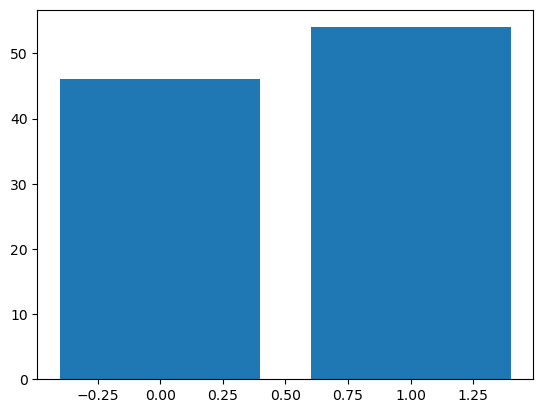

In [74]:
plt.bar([0, 1], [tails_count, heads_count])

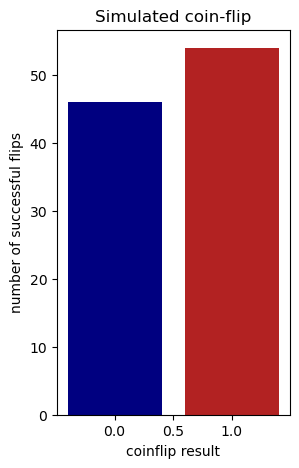

In [78]:
plt.figure(figsize=(3, 5))
plt.bar(x = [0, 1], height = [tails_count, heads_count], label=['tails', 'heads'], color=['navy', 'firebrick'])
plt.ylabel('number of successful flips')
plt.xlabel('coinflip result')
plt.title('Simulated coin-flip')
plt.savefig('coin_flip_figure.png')

## Pandas-seaborn

In [79]:
fair_coin

array([1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1])

In [ ]:
unfair_coin = np.random.binomial(n=1, p=.75, size=100)

In [82]:
import pandas as pd

ModuleNotFoundError: No module named 'pandas'

In [ ]:
fair_coin_df = pd.DataFrame({'observation': fair_coin, 'fair': 'fair'*len(fair_coin)})
fair_coin_df.head()

NameError: name 'pd' is not defined

In [ ]:
unfair_coin_df = pd.DataFrame({'observation': unfair_coin, 'fair': 'unfair'*len(unfair_coin)})

In [ ]:
coin_df = pd.concat([fair_coin, unfair_coin])

In [ ]:
coin_df.info()

In [ ]:
coin_df['observation']

In [ ]:
coin_df[coin_df['fair'] == 'fair']

In [ ]:
coin_df.groupby(['observation', 'fair']).count()

In [ ]:
pd.barplot(
    data = coin_df,
    x = 'observation',
    hue = 'fair',
    palette = 'Set1'
)

In [ ]:
coin_df.to_csv('../data/coin_data.csv', sep=',', index=False)

In [ ]:
coin_df = pd.read_csv('../data/coin_data.csv')
coin_df.head()